In [59]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from adjustText import adjust_text

    

sns.set_theme(style="whitegrid")    

plt.rcParams.update({
    "axes.titleweight": "bold",
    "font.size": 11,
    "axes.labelweight": "bold",
    "figure.dpi": 120,})

In [60]:
def load_summary(path="evaluation_summary.json"):
    with open(path, "r") as f:
        return json.load(f)


def build_palette(data):
    model_names = sorted({d["model"] for d in data})
    palette = sns.color_palette("tab10", n_colors=len(model_names))
    return dict(zip(model_names, palette))


def extract_overall(summary):
    data = []

    for model_name, model_data in summary.items():
        overall = model_data.get("overall", {})

        data.append({
            "model": model_name,
            "win_rate": overall.get("win_rate", 0),
            "avg_turn": overall.get("avg_found_solution_turn", np.nan),
            "info_gain": overall.get("avg_info_gain_per_suggestion", 0),
            "memory": overall.get("memory_score", 0),
            "repeated": overall.get("avg_repeated_suggestions", 0),
            "wrong_acc": overall.get("wrong_accusations", 0),
        })
    return data
summary = load_summary()

data = extract_overall(summary)
palette = build_palette(data)




In [61]:
def plot_win_rate(data, palette):
    data_sorted = sorted(data, key=lambda x: x["win_rate"])
    models = [d["model"] for d in data_sorted]
    values = [d["win_rate"] for d in data_sorted]
    colors = [palette[m] for m in models]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=values, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)

    for i, v in enumerate(values):
        ax.text(v + 0.01, i, f"{v:.0%}", va="center", ha="left", fontsize=10)

    ax.set_xlim(0, 1)
    ax.set_xlabel("Win rate")
    ax.set_ylabel("")
    ax.set_title("Model Performance: Win Rate")
    sns.despine(ax=ax, left=True, bottom=False)

    fig.tight_layout()
    fig.savefig("win_rate.png", dpi=300)
    plt.show()

In [62]:
def plot_efficiency(data, palette):
    x = [d["avg_turn"] for d in data]
    y = [d["info_gain"] for d in data]
    labels = [d["model"] for d in data]
    colors = [palette[m] for m in labels]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, s=200, c=colors, edgecolors="black", linewidth=0.8)

    for xi, yi, label in zip(x, y, labels):
        ax.text(xi + 0.12, yi + 0.02, label, fontsize=10, weight="bold")

    ax.set_xlabel("Avg solution turn (lower is better)")
    ax.set_ylabel("Info gain per suggestion")
    ax.set_title("Reasoning Efficiency Frontier")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig("efficiency.png", dpi=300)
    plt.show()

In [63]:
def plot_memory(data, palette):
    x = [d["memory"] for d in data]
    y = [d["repeated"] for d in data]
    labels = [d["model"] for d in data]
    colors = [palette[m] for m in labels]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, s=200, c=colors, edgecolors="black", linewidth=0.8)

    for xi, yi, label in zip(x, y, labels):
        ax.text(xi + 0.02, yi + 0.08, label, fontsize=10, weight="bold")

    ax.set_xlabel("Memory score (higher better)")
    ax.set_ylabel("Repeated suggestions (lower better)")
    ax.set_title("Memory vs Repetition")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig("memory.png", dpi=300)
    plt.show()

In [64]:
def plot_failures(data, palette):
    models = [d["model"] for d in data]
    failures = [d["wrong_acc"] for d in data]

    order = np.argsort(failures)
    models = [models[i] for i in order]
    failures = [failures[i] for i in order]
    colors = [palette[m] for m in models]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=failures, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)

    offset = max(0.3, max(failures) * 0.02) if failures else 0.3
    for i, v in enumerate(failures):
        ax.text(v + offset, i, str(v), va="center", ha="left", fontsize=10)

    ax.set_xlabel("Wrong accusations")
    ax.set_ylabel("")
    ax.set_title("Safety / Reliability: Failure Rate")

    sns.despine(ax=ax, left=True, bottom=False)    
    plt.show()

    fig.savefig("failures.png", dpi=300)
    fig.tight_layout()

/tmp/ipykernel_185623/1638304116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)


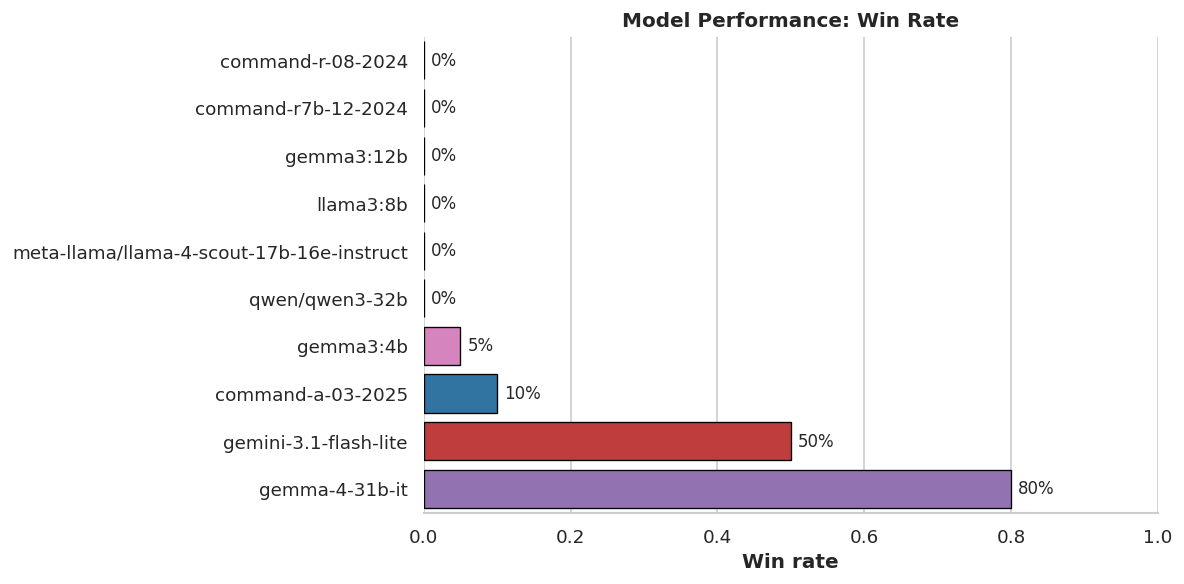

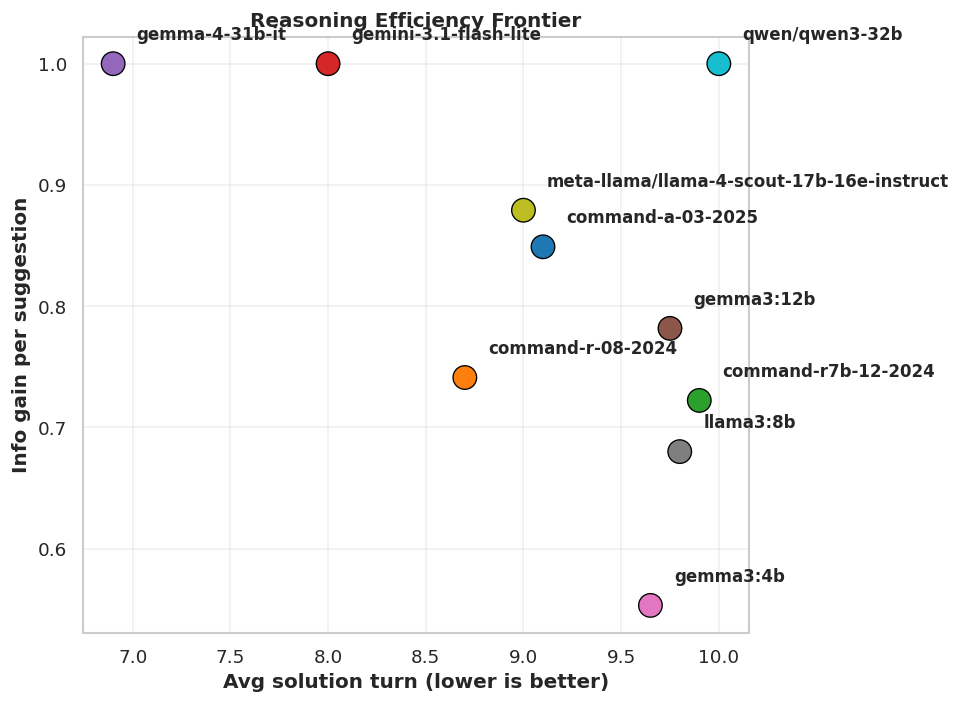

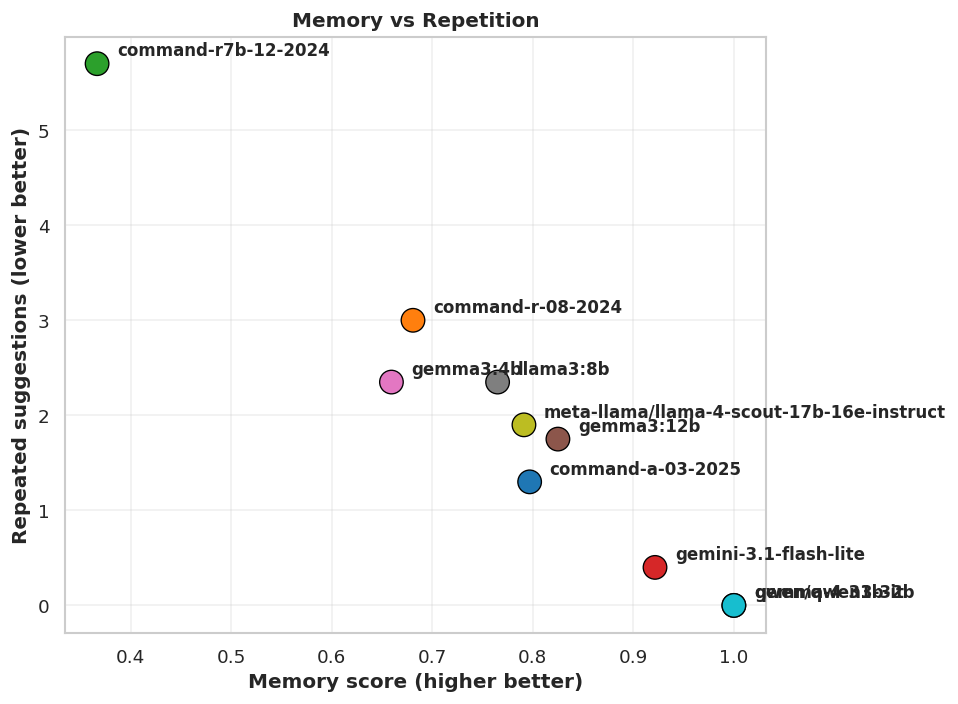

/tmp/ipykernel_185623/3866946267.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failures, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)


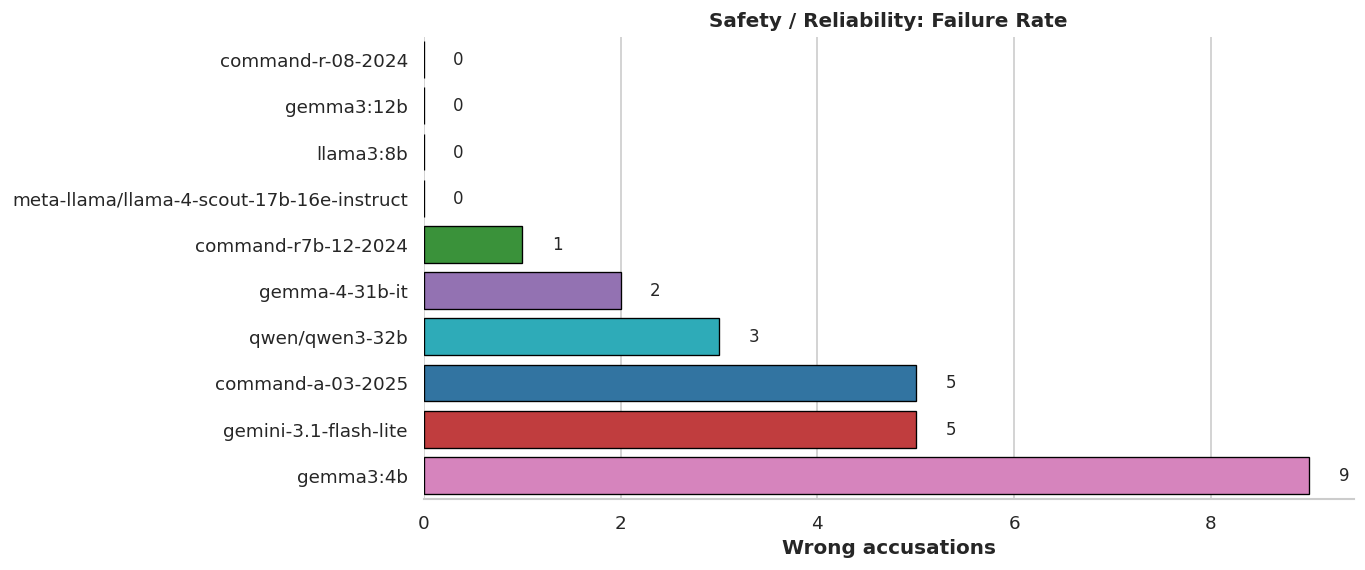

In [65]:
def run_all():
    plot_win_rate(data, palette)
    plot_efficiency(data, palette)
    plot_memory(data, palette)
    plot_failures(data, palette)

run_all()

In [66]:
def load_data(path="evaluation_summary.json"):
    with open(path, "r") as f:
        return json.load(f)

data = load_data()

In [67]:
def to_rows(summary):
    rows = []

    for model, content in summary.items():
        
        # overall
        overall = content.get("overall", {})
        rows.append({
            "model": model,
            "position": "overall",
            **overall
        })

        # positions
        for k, v in content.items():
            if k.startswith("position_"):
                rows.append({
                    "model": model,
                    "position": k,
                    **v
                })

    return pd.DataFrame(rows)

df = to_rows(data)

In [68]:
def plot_pareto(df):
    d = df[df["position"] == "overall"].copy()

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=d,
        x="avg_info_gain_per_suggestion",
        y="win_rate",
        s=200,
        hue="model"
    )



    plt.title("Pareto Frontier: Reasoning vs Winning Ability")
    plt.xlabel("Info Gain per Suggestion")
    plt.ylabel("Win Rate")

    plt.legend()
    plt.tight_layout()
    plt.savefig("pareto_frontier.png")
    plt.show()

In [69]:
def plot_position_bias(df):
    pos = df[df["position"] != "overall"].copy()

    agg = pos.groupby(["model", "position"])[
        ["win_rate", "avg_info_gain_per_suggestion", "avg_suggestions"]
    ].mean().reset_index()

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=agg,
        x="position",
        y="win_rate",
        hue="model",
        marker="o"
    )

    plt.title("Position Bias: Win Rate vs Player Order")
    plt.xlabel("Player Position")
    plt.ylabel("Win Rate")

    plt.tight_layout()
    plt.savefig("position_bias.png")
    plt.show()

In [70]:
def plot_fingerprint(df):
    d = df[df["position"] == "overall"].copy()

    features = [
        "win_rate",
        "avg_info_gain_per_suggestion",
        "avg_suggestions",
        "avg_repeated_suggestions",
        "memory_score",
        "wrong_accusations",
        "invalid_action",
        "invalid_notebook"
    ]

    mat = d.set_index("model")[features]

    # normalize for comparability
    mat = (mat - mat.mean()) / mat.std()

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        mat,
        annot=False,
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title("Behavior Fingerprint (Z-normalized)")
    plt.tight_layout()
    plt.savefig("behavior_fingerprint.png")
    plt.show()

In [71]:
def plot_radar(df):
    d = df[df["position"] == "overall"].copy()

    categories = [
        "wrong_accusations",
        "invalid_action",
        "invalid_notebook",
        "avg_repeated_suggestions",
        "avg_suggestions"
    ]

    models = d["model"].tolist()

    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for _, row in d.iterrows():
        values = [row[c] for c in categories]
        values += values[:1]

        ax.plot(angles, values, linewidth=2, label=row["model"])
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    plt.title("Failure Mode Radar")
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.savefig("failure_radar.png")
    plt.show()

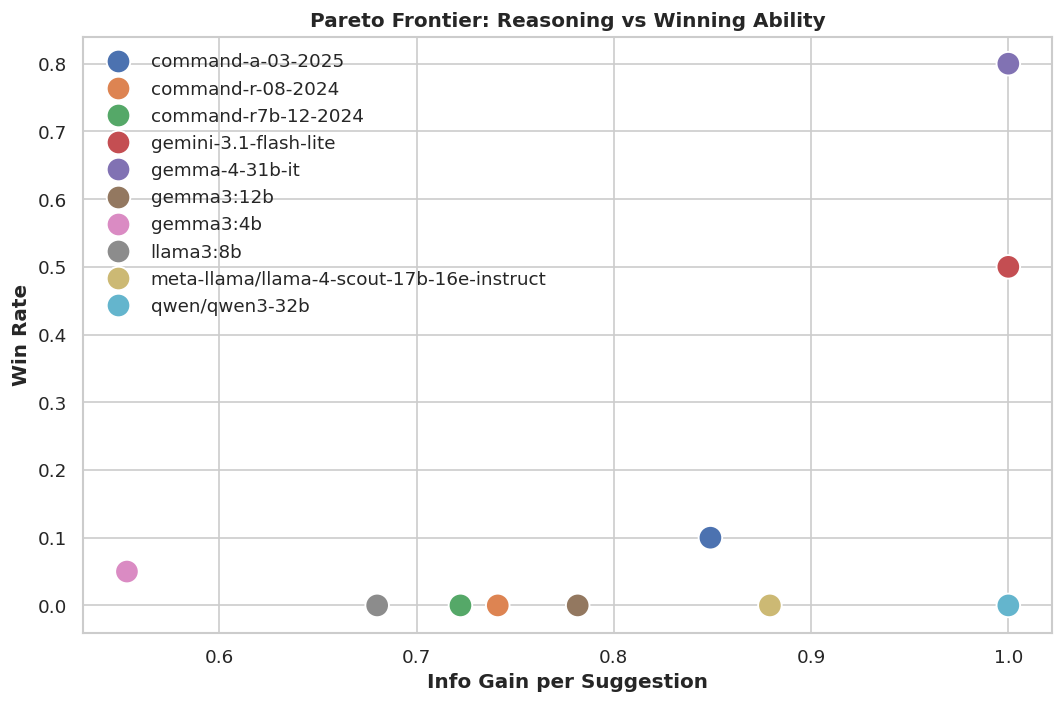

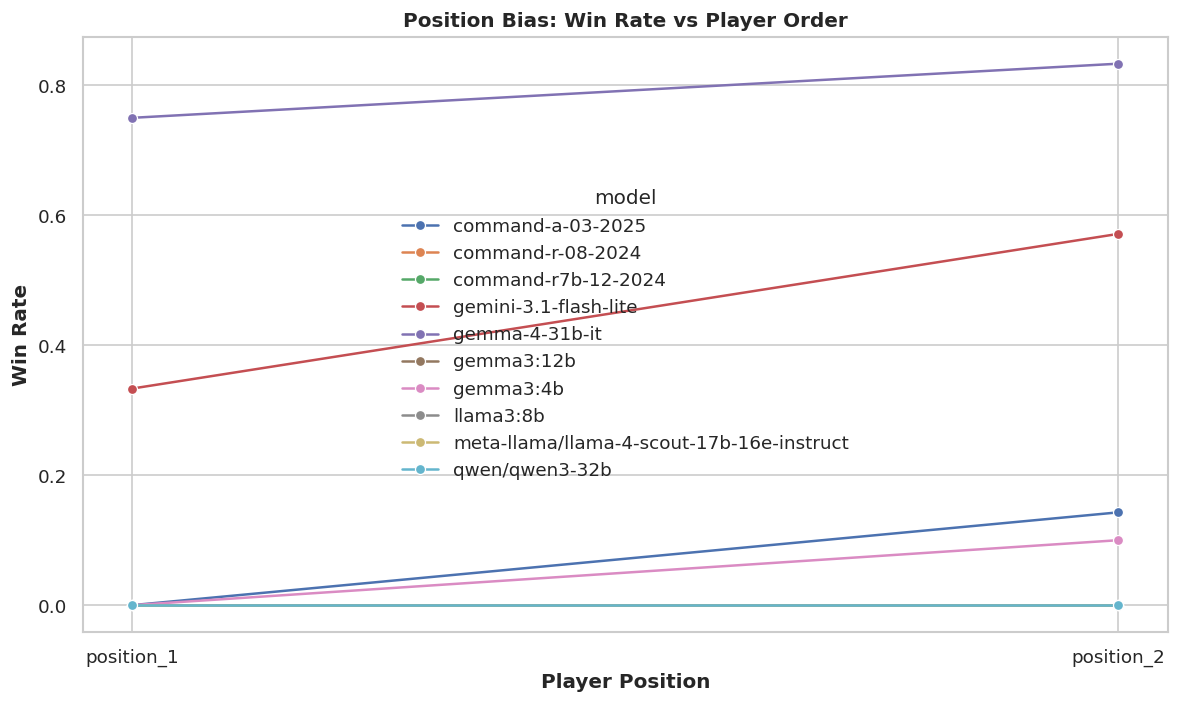

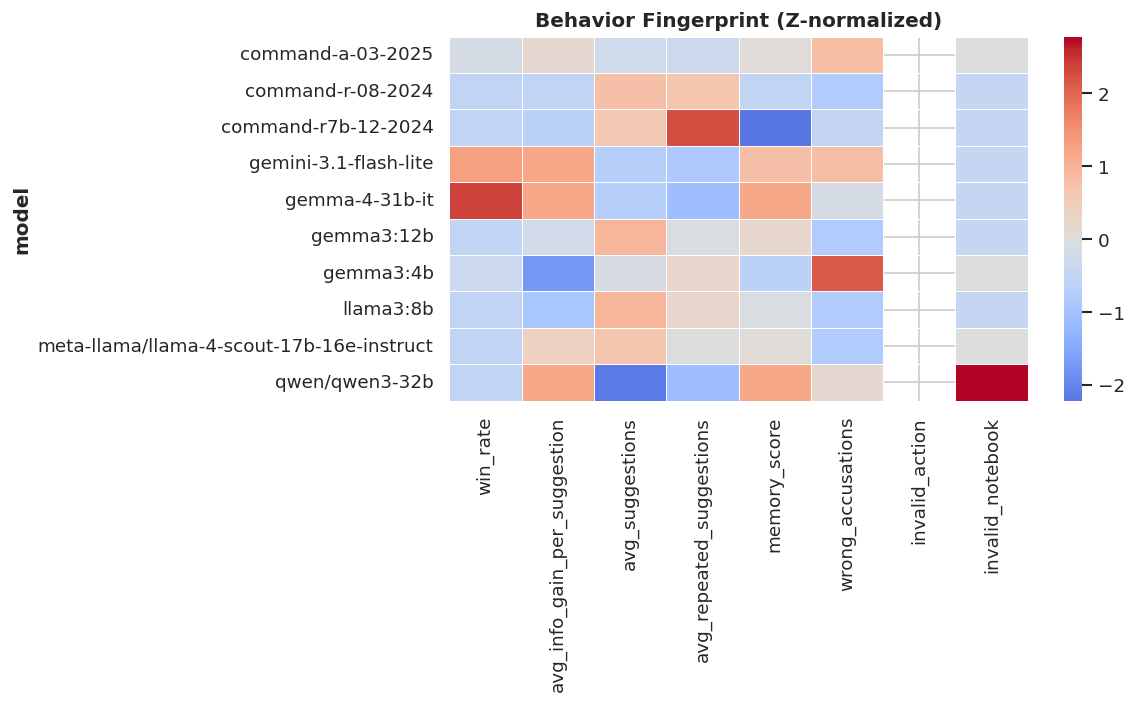

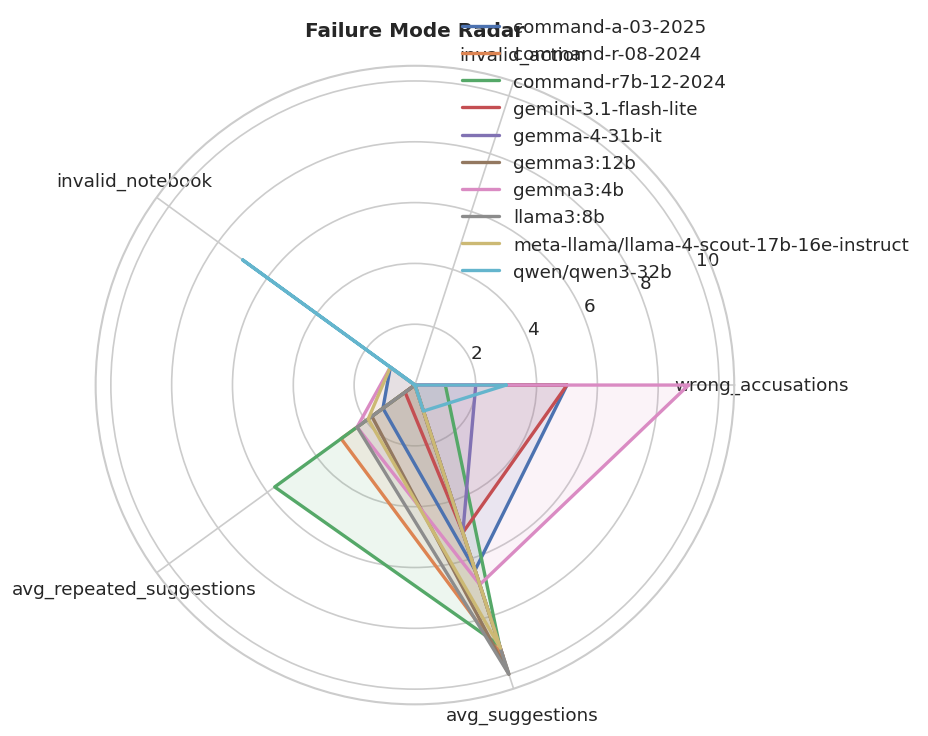

In [72]:
plot_pareto(df)
plot_position_bias(df)
plot_fingerprint(df)
plot_radar(df)